# Audio Classification with CNNs

In [37]:
import os

import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [38]:
def create_spectrogram(audio_file, image_file):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

    y, sr = librosa.load(audio_file)
    ms = librosa.feature.melspectrogram(y=y, sr=sr)
    log_ms = librosa.power_to_db(ms, ref=np.max)
    librosa.display.specshow(log_ms, sr=sr)

    fig.savefig(image_file)
    plt.close(fig)


def create_pngs_from_wavs(input_path, output_path):
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    dir = os.listdir(input_path)

    for i, file in enumerate(dir):
        input_file = os.path.join(input_path, file)
        output_file = os.path.join(output_path, file.replace(".wav", ".png"))
        create_spectrogram(input_file, output_file)

In [39]:
create_pngs_from_wavs("Sounds/background", "Spectrograms/background")
create_pngs_from_wavs("Sounds/chainsaw", "Spectrograms/chainsaw")
create_pngs_from_wavs("Sounds/engine", "Spectrograms/engine")
create_pngs_from_wavs("Sounds/storm", "Spectrograms/storm")

In [40]:
from tensorflow.keras.preprocessing import image


def load_images_from_path(path, label):
    images, labels = [], []

    for file in os.listdir(path):
        images.append(
            image.img_to_array(
                image.load_img(os.path.join(path, file), target_size=(224, 224, 3))
            )
        )
        labels.append((label))

    return images, labels


def show_images(images):
    fig, axes = plt.subplots(
        1, 8, figsize=(20, 20), subplot_kw={"xticks": [], "yticks": []}
    )

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i] / 255)


X, y = [], []

for i, target in enumerate(["background", "chainsaw", "engine", "storm"]):
    images, labels = load_images_from_path("Spectrograms/" + target, i)
    X += images
    y += labels

In [41]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.mobilenet import preprocess_input

X = preprocess_input(np.array(X))
y = np.array(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=0
)

In [42]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3)
)

train_features = base_model.predict(X_train)
test_features = base_model.predict(X_test)

4/4 [==============================] - 0s 90ms/step


In [43]:
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dense(4, activation="softmax"))
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [44]:
hist = model.fit(
    train_features,
    y_train,
    validation_data=(test_features, y_test),
    batch_size=10,
    epochs=10,
)

Epoch 1/10
28/28 [==============================] - 1s 22ms/step - loss: 25.2757 - accuracy: 0.6143 - val_loss: 4.1377 - val_accuracy: 0.7750
Epoch 2/10
28/28 [==============================] - 1s 21ms/step - loss: 1.4982 - accuracy: 0.9357 - val_loss: 2.0366 - val_accuracy: 0.9167
Epoch 3/10
28/28 [==============================] - 1s 21ms/step - loss: 0.3006 - accuracy: 0.9750 - val_loss: 2.3455 - val_accuracy: 0.8917
Epoch 4/10
28/28 [==============================] - 1s 21ms/step - loss: 0.2555 - accuracy: 0.9821 - val_loss: 1.3900 - val_accuracy: 0.9167
Epoch 5/10
28/28 [==============================] - 1s 21ms/step - loss: 0.2077 - accuracy: 0.9893 - val_loss: 4.5882 - val_accuracy: 0.8333
Epoch 6/10
28/28 [==============================] - 1s 21ms/step - loss: 0.1119 - accuracy: 0.9857 - val_loss: 7.4202 - val_accuracy: 0.7917
Epoch 7/10
28/28 [==============================] - 1s 21ms/step - loss: 0.5655 - accuracy: 0.9643 - val_loss: 1.3577 - val_accuracy: 0.9500
Epoch 8/10
2

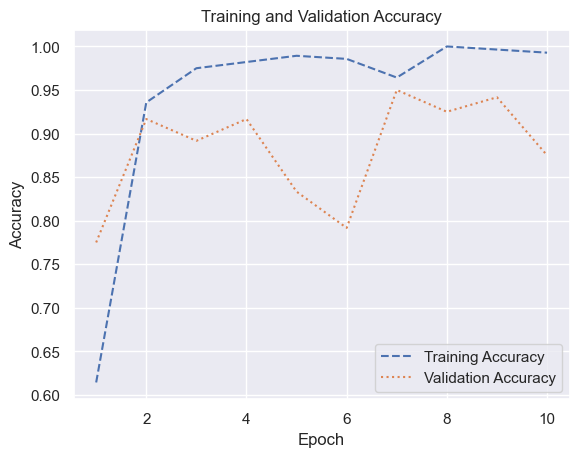

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "--", label="Training Accuracy")
plt.plot(epochs, val_acc, ":", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right");

4/4 [==============================] - 0s 10ms/step


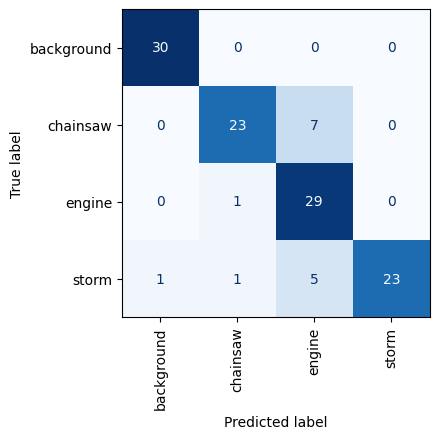

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd

sns.reset_orig()

fig, ax = plt.subplots(figsize=(4, 4))
ax.grid(False)

y_pred = model.predict(test_features)
class_labels = ["background", "chainsaw", "engine", "storm"]
cmd.from_predictions(
    y_test,
    y_pred.argmax(axis=1),
    display_labels=class_labels,
    colorbar=False,
    cmap="Blues",
    xticks_rotation="vertical",
    ax=ax,
)
plt.show()

In [47]:
create_spectrogram("Sounds/samples/sample1.wav", "Spectrograms/sample1.png")

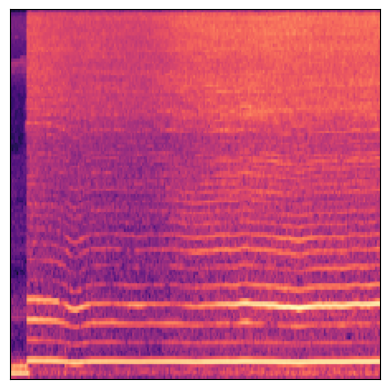

In [49]:
x = image.load_img("Spectrograms/sample1.png", target_size=(224, 224))
plt.xticks([])
plt.yticks([])
plt.imshow(x);

In [50]:
x = image.img_to_array(x)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

y = base_model.predict(x)
predictions = model.predict(y)

for i, label in enumerate(class_labels):
    print(f"{label}: {predictions[0][i]}")

1/1 [==============================] - 0s 12ms/step
background: 0.0
chainsaw: 1.0
engine: 2.0778415099620418e-10
storm: 0.0


In [51]:
create_spectrogram("Sounds/samples/sample2.wav", "Spectrograms/sample2.png")

1/1 [==============================] - 0s 13ms/step
background: 0.0
chainsaw: 6.072214671186404e-13
engine: 1.0
storm: 0.0


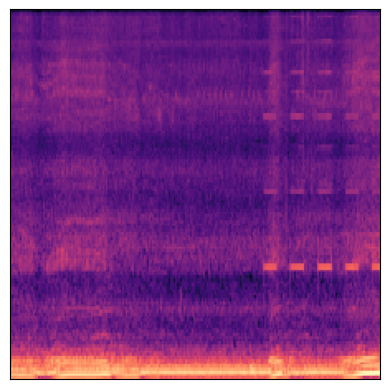

In [53]:
x = image.load_img("Spectrograms/sample2.png", target_size=(224, 224))
plt.xticks([])
plt.yticks([])
plt.imshow(x)

x = image.img_to_array(x)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

y = base_model.predict(x)
predictions = model.predict(y)

for i, label in enumerate(class_labels):
    print(f"{label}: {predictions[0][i]}")